In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

symboling: Рейтинг риска автомобиля (страховой показатель)..
CarName: Название или модель автомобиля.
aspiration: Тип наддува двигателя.
doornumber: Количество дверей в автомобиле.
carbody: Тип кузова автомобиля.
enginelocation: Расположение двигателя.
wheelbase: Колёсная база автомобиля.
carlength: Длина автомобиля.
carwidth: Ширина автомобиля.
carheight: Высота автомобиля.
curbweight: Снаряжённая масса автомобиля (вес без пассажиров и груза).
enginetype: Тип двигателя.
cylindernumber: Количество цилиндров в двигателе.
enginesize: Объём двигателя.
fuelsystem: Топливная система автомобиля.
boreratio: Диаметр цилиндра.
stroke: Ход поршня.
compressionratio: Степень сжатия.
horsepower: Мощность двигателя в лошадиных силах.
peakrpm: Максимальные обороты двигателя.
citympg: Расход топлива в городе (мили на галлон).
highwaympg: Расход топлива на шоссе (мили на галлон).
price: Цена автомобиля.

In [214]:
df=pd.read_csv("CarPrice_Assignment.csv")

In [215]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [216]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romeo giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romeo stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romeo Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [217]:
df.shape

(205, 26)

In [218]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [219]:
df.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

In [220]:
brands = ['alfa romeo', 'chevrolet', 'bmw', 'audi','dodge','honda','isuzu','jaguar','mazda','buick','mercury','mitsubishi','nissan','peugeot','plymouth','porsche','renault','saab','subaru','toyota','volkswagen','volvo']

In [221]:
def extract_brand(car_name):
    for brand in brands:
        if car_name.startswith(brand):
            return brand
    return car_name.split()[0] 
df['Brand'] = df['CarName'].apply(extract_brand)

In [200]:
df['cylindernumber'].value_counts()

cylindernumber
four      159
six        24
five       11
eight       5
two         4
three       1
twelve      1
Name: count, dtype: int64

In [222]:
str_to_num = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}
df['cylindernumber'] = df['cylindernumber'].map(str_to_num)

In [223]:
str_to_num = {
    'two': 2,
    'four': 4,
}
df['doornumber'] = df['doornumber'].map(str_to_num)

In [43]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,1,3,alfa-romeo giulia,gas,std,2,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,2,3,alfa-romeo stelvio,gas,std,2,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,3,1,alfa-romeo Quadrifoglio,gas,std,2,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,4,2,audi 100 ls,gas,std,4,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,4,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,4,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,202,-1,volvo 144ea,gas,turbo,4,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,203,-1,volvo 244dl,gas,std,4,sedan,rwd,front,109.1,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,204,-1,volvo 246,diesel,turbo,4,sedan,rwd,front,109.1,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


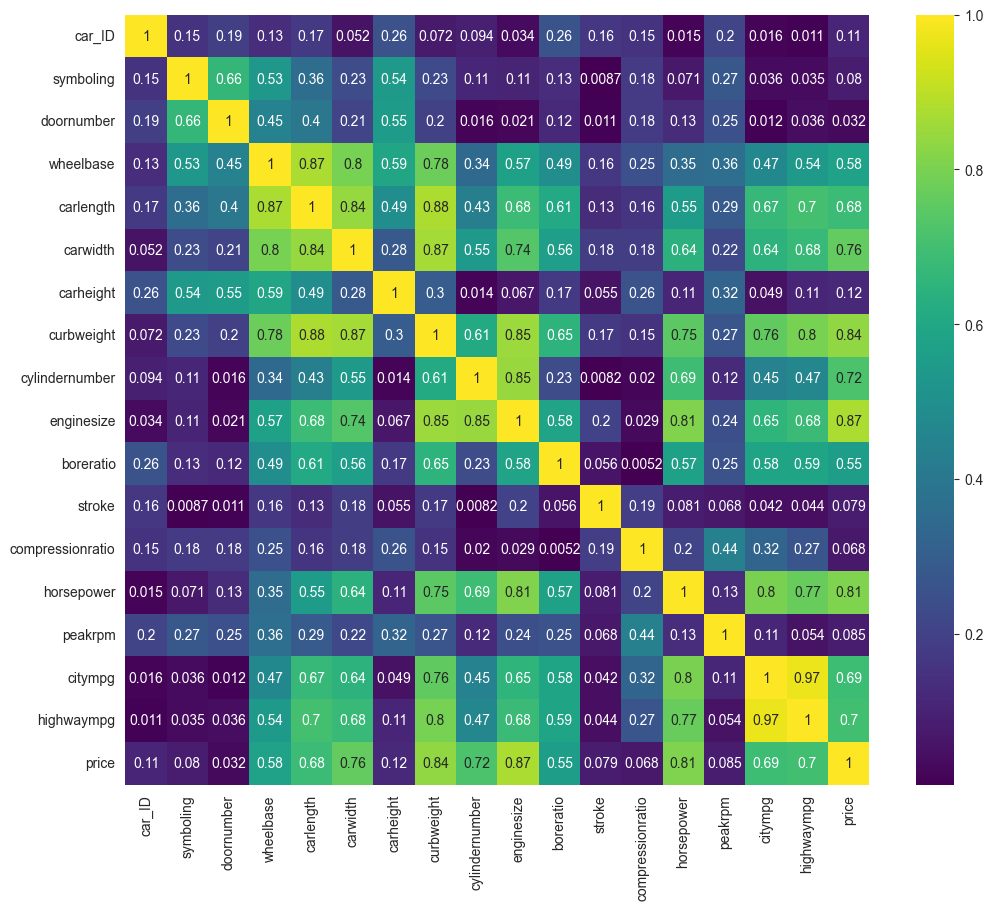

In [224]:
df_mod = df.select_dtypes(include=[float, int]) 
 
plt.figure(figsize = (12, 10)) 
sns.heatmap(abs(df_mod.corr()), annot = True, cmap="viridis") 
plt.show()

In [ ]:
sns.scatterplot(x='price',)

In [225]:
dtype_dict = {
    'fueltype': 'category',
    'aspiration': 'category',
    'carbody': 'category',
    'drivewheel': 'category',
    'enginelocation': 'category',
    'enginetype': 'category',
    'fuelsystem': 'category',
    'Brand': 'category',
}
df = df.astype(dtype_dict)

Text(0.5, 0, 'P-value')

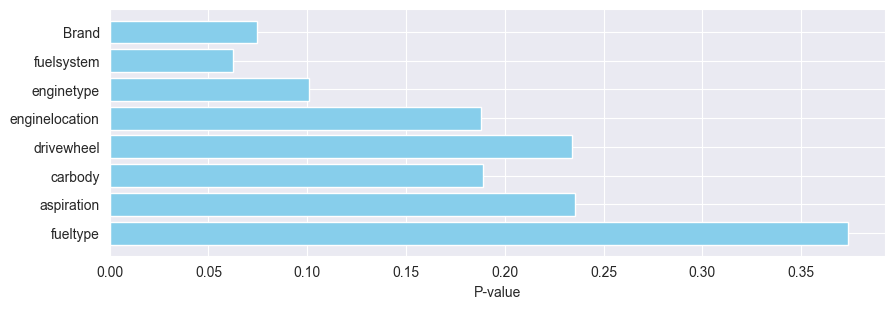

In [226]:
from scipy.stats import chi2_contingency
contingency_tables = {}
for column in df.columns:
    if column != 'price' and df[column].dtype == 'category': 
        contingency_table = pd.crosstab(df['price'], df[column])
        if not contingency_table.empty:
            chi2, p_value, _, _ = chi2_contingency(contingency_table)
            contingency_tables[column] = {'Chi-square': chi2, 'P-value': p_value}

attributes = list(contingency_tables.keys())
p_values = [table['P-value'] for table in contingency_tables.values()]
attributes = list(contingency_tables.keys())
p_values = [table['P-value'] for table in contingency_tables.values()]
plt.figure(figsize=(10, len(attributes) * 0.4))
plt.barh(attributes, p_values, color='skyblue')
plt.xlabel('P-value')

In [227]:
df=df.drop(columns=['car_ID','CarName'])

In [228]:
df

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand
0,3,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romeo
1,3,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romeo
2,1,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romeo
3,2,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,-1,gas,turbo,4,sedan,rwd,front,109.1,188.8,68.8,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,-1,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,-1,diesel,turbo,4,sedan,rwd,front,109.1,188.8,68.9,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


In [229]:
df['price_category']=pd.cut(df['price'],bins=[df['price'].min(),df['price'].median(),df['price'].max()],labels=['low','high'])

<Axes: xlabel='Brand', ylabel='count'>

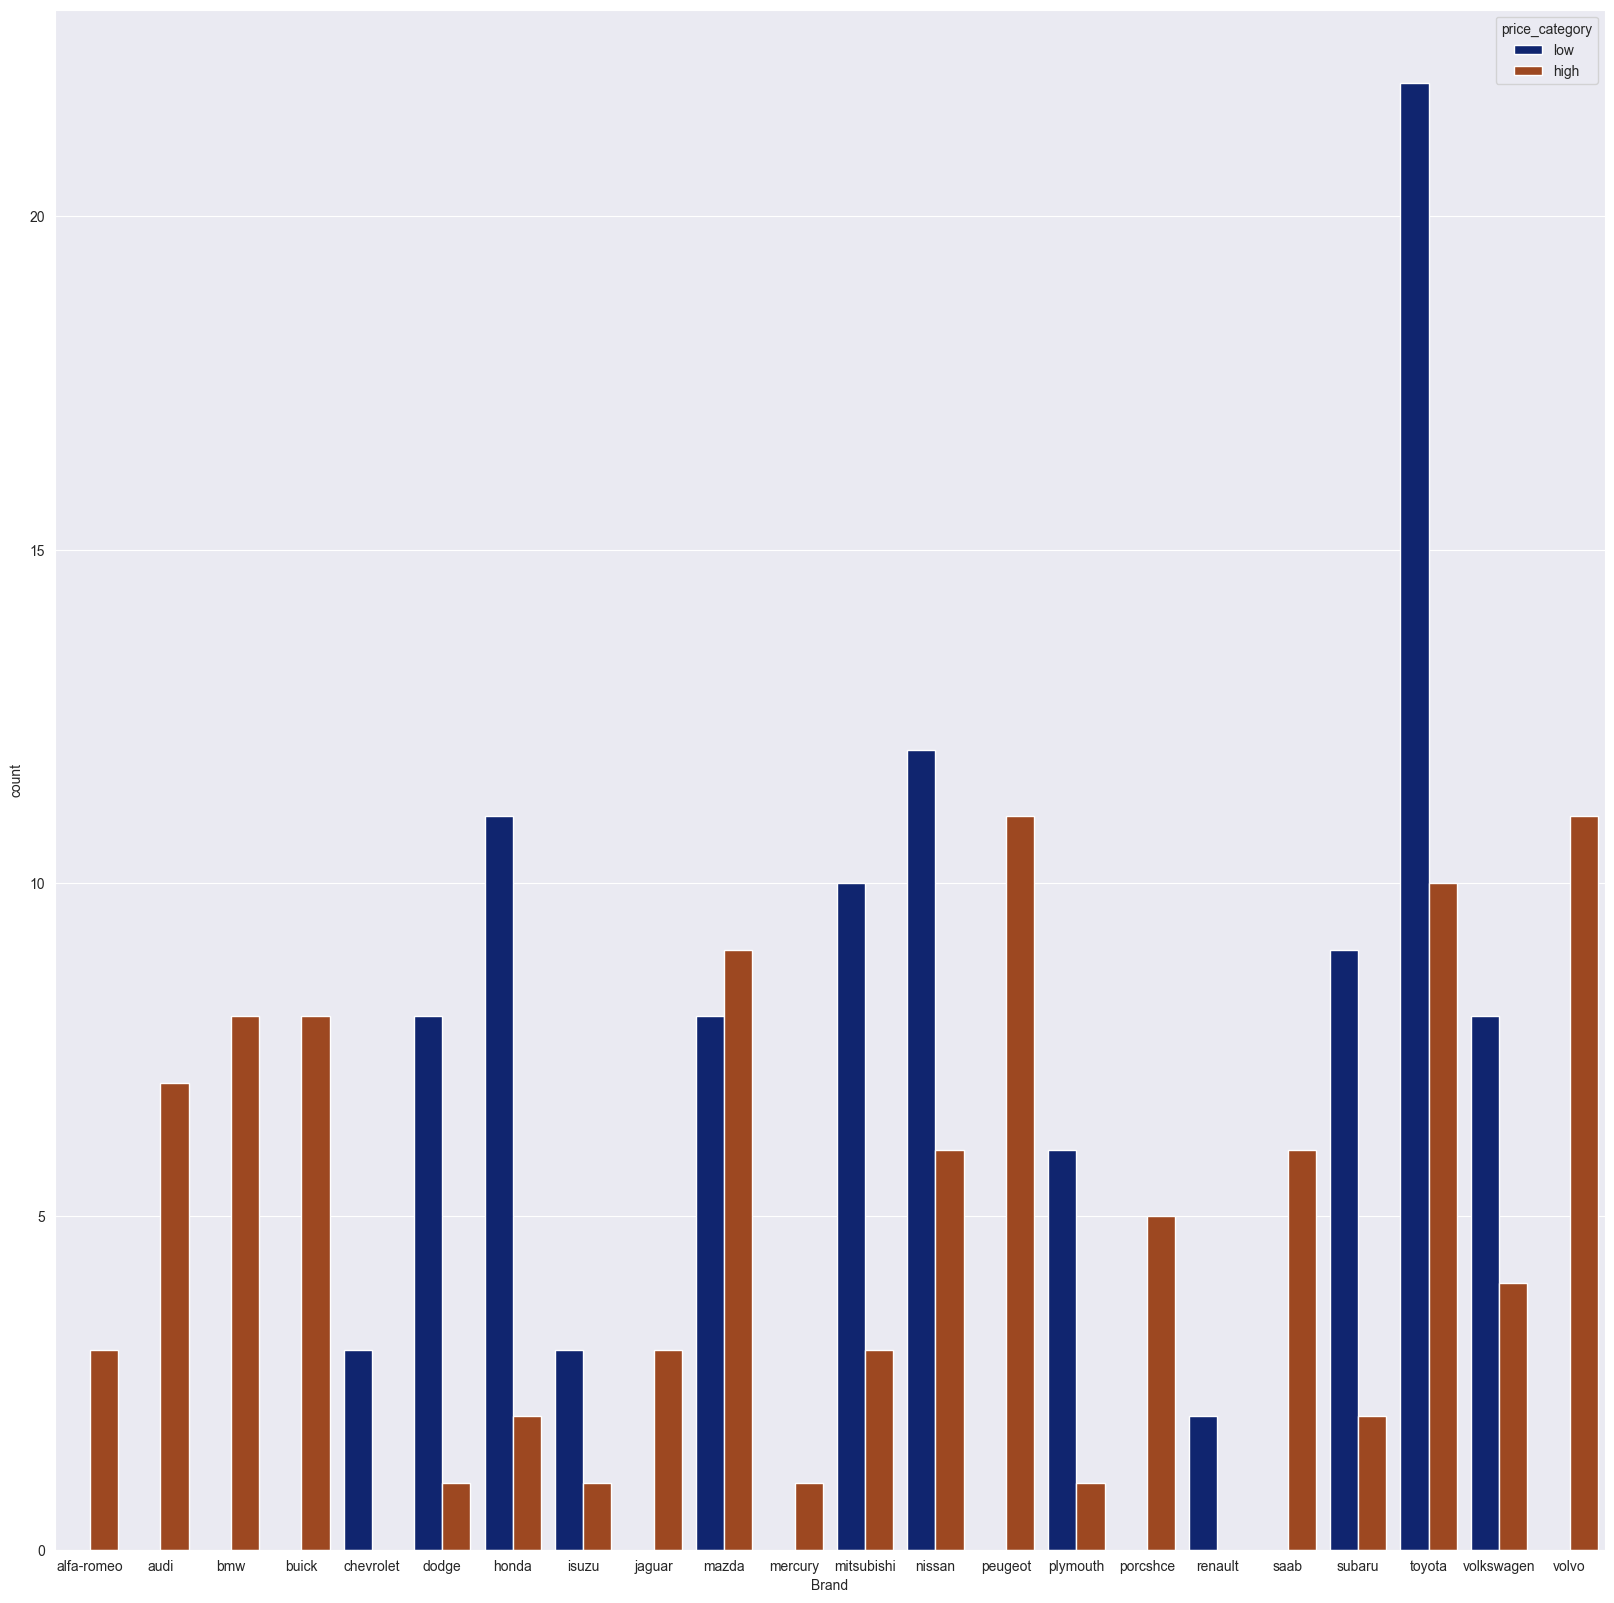

In [233]:
plt.figure(figsize=(20,20))
sns.countplot(data=df,x='Brand',hue='price_category',palette='dark')

In [205]:
df = pd.get_dummies(df, columns = ['fueltype', 
                                                      'aspiration', 
                                                      'carbody', 
                                                      'drivewheel', 
                                                      'enginelocation', 
                                                      'enginetype', 
                                                      'fuelsystem', 
                                                      'Brand'],drop_first = True)

In [206]:
df.shape

(205, 60)

In [210]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 30)
    max_depth = trial.suggest_int('max_depth', 2, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 30)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 30)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,  
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)

    return mae_test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=250)

best_params = study.best_params
best_mae = study.best_value

print(f'Best Mean Absolute Error on Test Set: {best_mae}')
print(f'Best Parameters: {best_params}')

[I 2024-05-31 22:33:17,528] A new study created in memory with name: no-name-cfb09e7e-739a-4369-a4ff-3f1b72e51b70
[I 2024-05-31 22:33:17,561] Trial 0 finished with value: 1705.0140718041182 and parameters: {'n_estimators': 19, 'max_depth': 15, 'min_samples_split': 11, 'min_samples_leaf': 5}. Best is trial 0 with value: 1705.0140718041182.
[I 2024-05-31 22:33:17,582] Trial 1 finished with value: 3665.1392316848805 and parameters: {'n_estimators': 13, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 22}. Best is trial 0 with value: 1705.0140718041182.
[I 2024-05-31 22:33:17,612] Trial 2 finished with value: 2177.459820480804 and parameters: {'n_estimators': 18, 'max_depth': 9, 'min_samples_split': 28, 'min_samples_leaf': 8}. Best is trial 0 with value: 1705.0140718041182.
[I 2024-05-31 22:33:17,631] Trial 3 finished with value: 3852.8337488562443 and parameters: {'n_estimators': 11, 'max_depth': 30, 'min_samples_split': 19, 'min_samples_leaf': 29}. Best is trial 0 with value:

Best Mean Absolute Error on Test Set: 1305.3741792165406
Best Parameters: {'n_estimators': 29, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 1}


In [208]:
df.columns

Index(['symboling', 'doornumber', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'cylindernumber', 'enginesize', 'boreratio',
       'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg',
       'highwaympg', 'price', 'fueltype_gas', 'aspiration_turbo',
       'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan',
       'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd',
       'enginelocation_rear', 'enginetype_dohcv', 'enginetype_l',
       'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'enginetype_rotor', 'fuelsystem_2bbl', 'fuelsystem_4bbl',
       'fuelsystem_idi', 'fuelsystem_mfi', 'fuelsystem_mpfi',
       'fuelsystem_spdi', 'fuelsystem_spfi', 'Brand_audi', 'Brand_bmw',
       'Brand_buick', 'Brand_chevrolet', 'Brand_dodge', 'Brand_honda',
       'Brand_isuzu', 'Brand_jaguar', 'Brand_mazda', 'Brand_mercury',
       'Brand_mitsubishi', 'Brand_nissan', 'Brand_peugeot', 'Brand_plymouth',
       'Brand_porcshce', 'Brand_renault